In [54]:
using BSON: @load
using DriftDiffusionModels
using HiddenMarkovModels
using MultivariateStats
using Clustering
using DataFrames
using HypothesisTests
using Distances
using StatsBase
using StatsPlots
using Plots
using Base.Threads: @threads

In [2]:
using BSON: @load
using DriftDiffusionModels
using Plots

# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

In [3]:
ddm_params = Matrix{Float64}(undef, 4, 18 * 4) # 4 parameters per DDM, (18 subjects x 4 states)

for (i, fit) in enumerate(ddmhmm_fits)
    for k in 1:4
        ddm = fit.hmm.dists[k]
        ddm_params[:, (i - 1) * 4 + k] = [ddm.v, ddm.B, ddm.a₀, ddm.τ]
    end
end

ddm_params_df = DataFrame(ddm_params', [:v, :B, :a0, :tau])
animal_files = [split(fname, "\\")[end] for fname in bson_files]
animal_name  = [split(file, "_")[1] for file in animal_files]

ddm_params_df.rat = repeat(animal_name, inner=4);

ddm_params_clean = Matrix(select(ddm_params_df, Not(:rat))) # for numerical analyses

# standardize first if need later
zscore(x; dims) = (x .- mean(x; dims=dims)) ./ std(x; dims=dims)
ddm_params_z = zscore(ddm_params_clean'; dims=2)

4×72 Matrix{Float64}:
  0.0884106   0.0123428  -0.159011  …  -0.623018    -0.135475   -0.299235
 -0.329032   -0.153295   -0.494668      0.00684298  -0.333599   -0.473151
 -1.05581    -0.630828   -0.70414      -0.186832    -0.236163    0.290069
  0.833301    1.09977     0.424557     -2.15416     -0.0134415  -0.466619

In [46]:
accs = Vector{Float64}(undef, size(ddm_params_df, 1))
mean_rt = Vector{Float64}(undef, size(ddm_params_df, 1))
for (idx, i) in enumerate(eachrow(ddm_params_df))
    ddm = DriftDiffusionModels.DriftDiffusionModel(v=i.v, B=i.B, a₀=i.a0, τ=i.tau)
    data = simulateDDM(ddm, 10000)
    is_correct = [d.s == d.choice for d in data]
    rts = [d.rt for d in data]
    accs[idx] = mean(is_correct)
    mean_rt[idx] = mean(rts)
end
ddm_params_df.acc = accs;
ddm_params_df.mean_rt = mean_rt;

In [41]:

function high_low_by_rat(df::DataFrame; acc::Symbol=:acc)
    g = groupby(df, :rat)

    high = combine(g) do sdf
        sdf[argmax(sdf[!, acc]), :]
    end

    low = combine(g) do sdf
        sdf[argmin(sdf[!, acc]), :]
    end

    rename!(high, Symbol.(names(high)) .=> Symbol.(string.(names(high)) .* "_high"))
    rename!(low,  Symbol.(names(low))  .=> Symbol.(string.(names(low))  .* "_low"))

    return innerjoin(high, low, on = :rat_high => :rat_low)
end

hl = high_low_by_rat(ddm_params_df)

hl.Δv   = hl.v_high   .- hl.v_low
hl.Δa   = hl.B_high   .- hl.B_low
hl.Δa0  = hl.a0_high  .- hl.a0_low
hl.Δτ   = hl.tau_high .- hl.tau_low

function paired_spaghetti(hl::DataFrame, low::Symbol, high::Symbol; title="")
    lo = hl[!, low]
    hi = hl[!, high]
    n = length(lo)

    p = plot(size =(500,500), xticks=([1,2], ["Low", "High"]), title=title, legend=false)
    for i in 1:n
        plot!(p, [1,2], [lo[i], hi[i]], lw=1, alpha=0.6)
        scatter!(p, [1,2], [lo[i], hi[i]], alpha=0.8, ms=4)
    end

    return p
end

delta_tau = paired_spaghetti(hl, :tau_low, :tau_high; title="τ")
delta_a0  = paired_spaghetti(hl, :a0_low,  :a0_high;  title="a₀")
delta_B   = paired_spaghetti(hl, :B_low,   :B_high;   title="B")
delta_v   = paired_spaghetti(hl, :v_low,   :v_high;   title="v")

param_diff_plot = plot(delta_v, delta_B, delta_a0, delta_tau; layout=(2,2))
savefig(param_diff_plot, "../results/param_diff_plot_population.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\param_diff_plot_population.svg"

In [34]:
function paired_tests(hl::DataFrame, Δ::Symbol)
    x = skipmissing(hl[!, Δ]) |> collect

    t  = OneSampleTTest(x)      # mean(Δ) = 0
    w  = SignedRankTest(x)      # median(Δ) = 0 (robust default)

    return (
        n = length(x),
        mean = mean(x),
        median = median(x),
        t_p = pvalue(t),
        w_p = pvalue(w),
    )
end

paired_tests(hl, :Δa0)

(n = 18, mean = -0.06785615624039906, median = -0.016179928479726866, t_p = 0.20264336493199106, w_p = 0.34654998779296875)

In [42]:
hl.bias_high = hl.a0_high .- 0.5
hl.bias_low  = hl.a0_low  .- 0.5

18-element Vector{Float64}:
 -0.15322086769446558
  0.29299697149744786
 -0.3324027874175953
 -0.13940793631910076
 -0.1107893613782045
 -0.05705763348679038
  0.022469553452539537
  0.18946905820707804
  0.011012010065420408
  0.11405332943944624
 -0.2906713774418699
 -0.25623240148043425
 -0.09850905841603469
  0.021746474185370235
  0.3744889347762992
  0.4965852565987061
 -0.22759144691796962
 -0.07311295451841626

In [ ]:
SignedRankTest(hl.bias_high) |> pvalue
SignedRankTest(hl.bias_low)  |> pvalue

0.00896453857421875

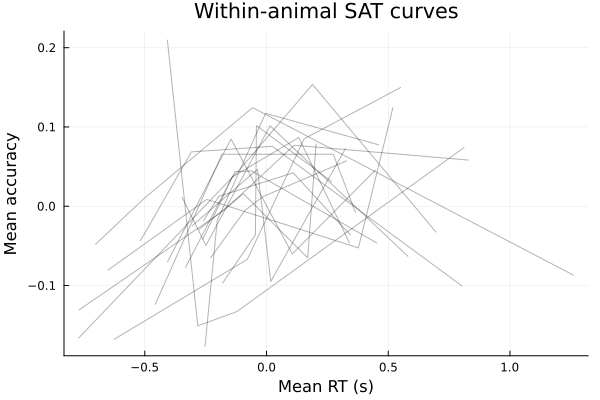

In [65]:
# SAT curvs
function center_within_animal(df::DataFrame;
    rat::Symbol=:rat, rt::Symbol=:mean_rt, acc::Symbol=:mean_acc)

    g = groupby(df, rat)

    return DataFrames.transform(g,
        rt  => (x -> x .- mean(x))  => :rt_c,
        acc => (x -> x .- mean(x))  => :acc_c,
    )
end

dfc = center_within_animal(ddm_params_df; rat=:rat, rt=:mean_rt, acc=:acc)

function plot_sat_spaghetti(df::DataFrame;
    rt::Symbol=:mean_rt,
    acc::Symbol=:acc,
    rat::Symbol=:rat,
    title::String="Within-animal SAT curves")

    p = plot(title=title, xlabel="Mean RT (s)", ylabel="Mean accuracy",
             legend=false)

    for sdf in groupby(df, rat)
        # sort points within animal by RT so the line doesn't jump around
        ord = sortperm(sdf[!, rt])
        x = sdf[ord, rt]
        y = sdf[ord, acc]

        plot!(p, x, y, lw=1, color=:black, alpha=0.3)

    end

    return p
end

p = plot_sat_spaghetti(dfc; rt=:rt_c, acc=:acc_c, rat=:rat)

In [68]:
# 1) add within-rat RT order (1..K)
function add_rt_order(df::DataFrame; rat::Symbol=:rat, rt::Symbol=:rt_c)
    g = groupby(df, rat)
    return DataFrames.transform(g, rt => (x -> invperm(sortperm(x))) => :rt_order)
end

# 2) overlay mean SAT curve (+/- SEM ribbon) onto an existing plot
function overlay_mean_sat!(p, df::DataFrame;
    rt::Symbol=:rt_c, acc::Symbol=:acc_c, order::Symbol=:rt_order)

    summ = combine(groupby(df, order),
        rt  => mean => :rt_mean,
        acc => mean => :acc_mean,
        acc => (x -> std(x)/sqrt(length(x))) => :acc_sem
    )
    sort!(summ, order)

    plot!(p, summ.rt_mean, summ.acc_mean, lw=5, alpha=1.0, color=:black)
    plot!(p, summ.rt_mean, summ.acc_mean, ribbon=summ.acc_sem, fillalpha=0.15, color=:black,lw=0)
    return p
end

dfc2 = add_rt_order(dfc; rat=:rat, rt=:rt_c)

overlay_mean_sat!(p, dfc2; rt=:rt_c, acc=:acc_c, order=:rt_order)

p

savefig(p, "../results/population_mean_sat.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\population_mean_sat.svg"

In [180]:
function parallel_analysis(X; n_iter=500)
    n, p = size(X)
    R = cor(X)
    eig_real = sort(eigvals(R); rev=true)

    eig_rand = zeros(n_iter, p)
    for i in 1:n_iter
        Xr = randn(n, p)
        eig_rand[i, :] = sort(eigvals(cor(Xr)); rev=true)
    end

    eig_mean = mean(eig_rand, dims=1)
    eig_95 = mapslices(x -> quantile(x, 0.95), eig_rand; dims=1)

    return eig_real, eig_mean[:], eig_95[:]
end

eig_real, eig_mean, eig_95 = parallel_analysis(ddm_params_z'[Not(37), :])

([1.832205717159037, 0.9538377605678167, 0.7291882748721973, 0.48476824740095004], [1.2656602147624145, 1.0701896240871558, 0.9174350635985458, 0.7467150975518839], [1.4089900383006462, 1.1579964028487377, 0.9960921924983341, 0.8646911580637302])

In [183]:
# Fit 2-factor FA model
fa = fit(FactorAnalysis, ddm_params_z[:, Not(37)]; maxoutdim=1)

# scores = predict(fa, ddm_params_z)'  # size: nrows × 2
# scatter(scores[:, 1], scores[:, 2]; group=ddm_params_df.rat, legend=false,
#     xlabel="Factor 1", ylabel="Factor 2", title="Factor Analysis of DDM Parameters")

Factor Analysis(indim = 4, outdim = 1)

In [174]:
out = argmax(scores)
println(out)

CartesianIndex(37, 1)


In [177]:
scores[37, :]

2-element Vector{Float64}:
 7.967807673186441
 1.6909414719940505

In [184]:
fa.W

4×1 Matrix{Float64}:
  0.2403873240884616
 -0.12700106418172602
 -0.33326456424828443
  0.6500700592231119